# Notebook 6: Evaluation & Inference
---
Evaluates the trained `HybridFashionModel` on the held-out test set, runs baseline comparisons, and demonstrates live inference.

**Prerequisites:** NB03 completed (all artifacts in `saved_models/`)

**Outputs:**
- `saved_models/test_evaluation_results.json`
- `saved_models/per_group_metrics.json`
- `saved_models/baseline_results.json`
- `plots/reliability_diagram.png`

## Step 1: Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

from scripts.config import SAVED_MODELS_DIR, DATA_PROCESSED_DIR, PLOTS_DIR

print("Setup complete.")

Setup complete.


## Step 2: Test Set Evaluation

Computes ROC-AUC, F1, accuracy, Brier score, and MAE on the held-out test split.
Each metric is computed independently — a failure in one does not block the others.
95% bootstrap confidence intervals (1,000 resamples) are reported for all primary metrics.

In [2]:
import subprocess

cmd = [sys.executable, "-m", "scripts.evaluate_test_set"]
print("Running test set evaluation...")
result = subprocess.run(cmd, cwd=str(Path("..").resolve()))

if result.returncode == 0:
    print("Evaluation complete.")
else:
    print(f"Evaluation failed with exit code {result.returncode}")

Running test set evaluation...
O4U Test Set Evaluator
  Project root    : /Users/hazron/O4U
  Test JSON       : /Users/hazron/O4U/data/raw/Outfit4You/label/test.json
  Saved models    : /Users/hazron/O4U/saved_models
  n_imputations   : 1

Test data loaded: 1 imputation(s), 2520 samples each.
Columns: ['id', 'score', 'is_processed', 'is_bad', 'item_1', 'item_2', 'item_3', 'item_4', 'item_5', 'item_6', 'item_7', 'item_8', 'item_9', 'binary_label', 'body_figure', 'height_was_imputed', 'breasts_was_imputed', 'skin_color_was_imputed', 'color_contrast_was_imputed', 'hair_style_was_imputed', 'hair_color_was_imputed', 'bf_athietic', 'bf_bottom_hourglass', 'bf_diamond', 'bf_hourglass', 'bf_inverted_triangle', 'bf_rectangle', 'bf_round', 'bf_spoon', 'bf_top_hourglass', 'bf_triangle', 'bf_unknown', 'skin_color_brown', 'skin_color_dark', 'skin_color_dark,brown', 'skin_color_dark,fair', 'skin_color_fair', 'skin_color_fair,brown', 'skin_color_unknown', 'skin_color_yellow', 'skin_color_yellow,brown'

2026-05-10 20:47:07 [INFO] __main__: Loading test data (n_imputations=1)…
2026-05-10 20:47:07 [INFO] __main__: Loaded test.json: 1574 samples, columns: ['id', 'score', 'is_processed', 'is_bad', 'item_1', 'item_2', 'item_3', 'item_4', 'item_5', 'item_6', 'item_7', 'item_8', 'item_9', 'body_figure', 'skin_color', 'hair_style', 'hair_color', 'height', 'breasts', 'color_contrast']
2026-05-10 20:47:07 [WARNING] __main__: test_imputed_manifest.json not found at /Users/hazron/O4U/data/processed/test_imputed_manifest.json. Falling back to val_imputed_manifest.json. Run the imputation pipeline on the test split to generate test_imputed_manifest.json.
2026-05-10 20:47:07 [INFO] __main__: Loaded imputed manifest: val_imputed_manifest.json (2520 rows)
2026-05-10 20:47:07 [INFO] __main__: Loading model and artifacts from /Users/hazron/O4U/saved_models…
2026-05-10 20:47:07 [INFO] __main__: Artifacts loaded — phys_feature_cols: 99 cols, threshold: 0.4000, score_mean: 1.4027, score_std: 0.8319
2026-05


Inference complete: 2520 samples, threshold=0.4000, n_imputations_pooled=1


2026-05-10 20:47:09 [INFO] __main__: Computing evaluation metrics…



Evaluation metrics:
  roc_auc        : 0.9443  95% CI [0.9353, 0.9531]
  f1             : 0.9191  95% CI [0.9081, 0.9297]
  accuracy       : 0.9024  95% CI [0.8905, 0.9139]
  brier_score    : 0.0834  95% CI [0.0753, 0.0912]
  mae            : 0.8080

Results saved to: /Users/hazron/O4U/saved_models/test_evaluation_results.json
Per-group metrics saved to: /Users/hazron/O4U/saved_models/per_group_metrics.json
Reliability diagram saved to: /Users/hazron/O4U/plots/reliability_diagram.png

Evaluation complete.


2026-05-10 20:47:11 [INFO] __main__: Saving evaluation results to test_evaluation_results.json…
2026-05-10 20:47:11 [INFO] __main__: Evaluation results saved to /Users/hazron/O4U/saved_models/test_evaluation_results.json
2026-05-10 20:47:11 [INFO] __main__: Computing per-group metrics…
2026-05-10 20:47:11 [INFO] __main__: Per-group metrics saved to /Users/hazron/O4U/saved_models/per_group_metrics.json
2026-05-10 20:47:11 [INFO] __main__: Generating reliability diagram…
2026-05-10 20:47:12 [INFO] __main__: Reliability diagram saved to /Users/hazron/O4U/plots/reliability_diagram.png (n_bins_used=10, brier_score=0.0834)


Evaluation complete.


## Step 3: Display Evaluation Results

In [3]:
results_path = SAVED_MODELS_DIR / "test_evaluation_results.json"

if results_path.exists():
    with open(results_path) as f:
        results = json.load(f)

    print("Test Set Evaluation Results")
    print("=" * 50)
    for metric, data in results.items():
        if metric == 'n_imputations_pooled':
            print(f"  Imputations pooled : {data}")
        elif isinstance(data, dict):
            val = data.get('value')
            lo  = data.get('ci_lower')
            hi  = data.get('ci_upper')
            if val is not None:
                ci_str = f"  [95% CI: {lo:.4f} – {hi:.4f}]" if lo is not None else ""
                print(f"  {metric:<20s}: {val:.4f}{ci_str}")
        elif data is not None:
            print(f"  {metric:<20s}: {data:.4f}")
else:
    print("test_evaluation_results.json not found — check evaluation output above.")

Test Set Evaluation Results
  roc_auc             : 0.9443  [95% CI: 0.9353 – 0.9531]
  f1                  : 0.9191  [95% CI: 0.9081 – 0.9297]
  accuracy            : 0.9024  [95% CI: 0.8905 – 0.9139]
  brier_score         : 0.0834  [95% CI: 0.0753 – 0.0912]
  mae                 : 0.8080
  Imputations pooled : 1


## Step 4: Per-Group Metrics

In [4]:
pg_path = SAVED_MODELS_DIR / "per_group_metrics.json"

if pg_path.exists():
    with open(pg_path) as f:
        pg = json.load(f)

    # Body figure breakdown
    bf_data = pg.get('by_body_figure', {})
    if bf_data:
        df_bf = pd.DataFrame(bf_data).T
        print("Per Body Figure Group:")
        print(df_bf.round(4).to_string())

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        df_bf['accuracy'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
        axes[0].set_title('Accuracy by Body Figure')
        axes[0].set_xlabel('Accuracy')
        df_bf['f1'].sort_values().plot(kind='barh', ax=axes[1], color='salmon')
        axes[1].set_title('F1 by Body Figure')
        axes[1].set_xlabel('F1')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'per_group_metrics.png', dpi=150, bbox_inches='tight')
        plt.show()

    # Imputed vs observed
    print("\nImputed rows :", pg.get('imputed_rows', {}))
    print("Observed rows:", pg.get('observed_rows', {}))
else:
    print("per_group_metrics.json not found.")


Imputed rows : {'accuracy': 0.9023809523809524, 'f1': 0.9191321499013807}
Observed rows: {}


## Step 5: Reliability Diagram (Calibration)

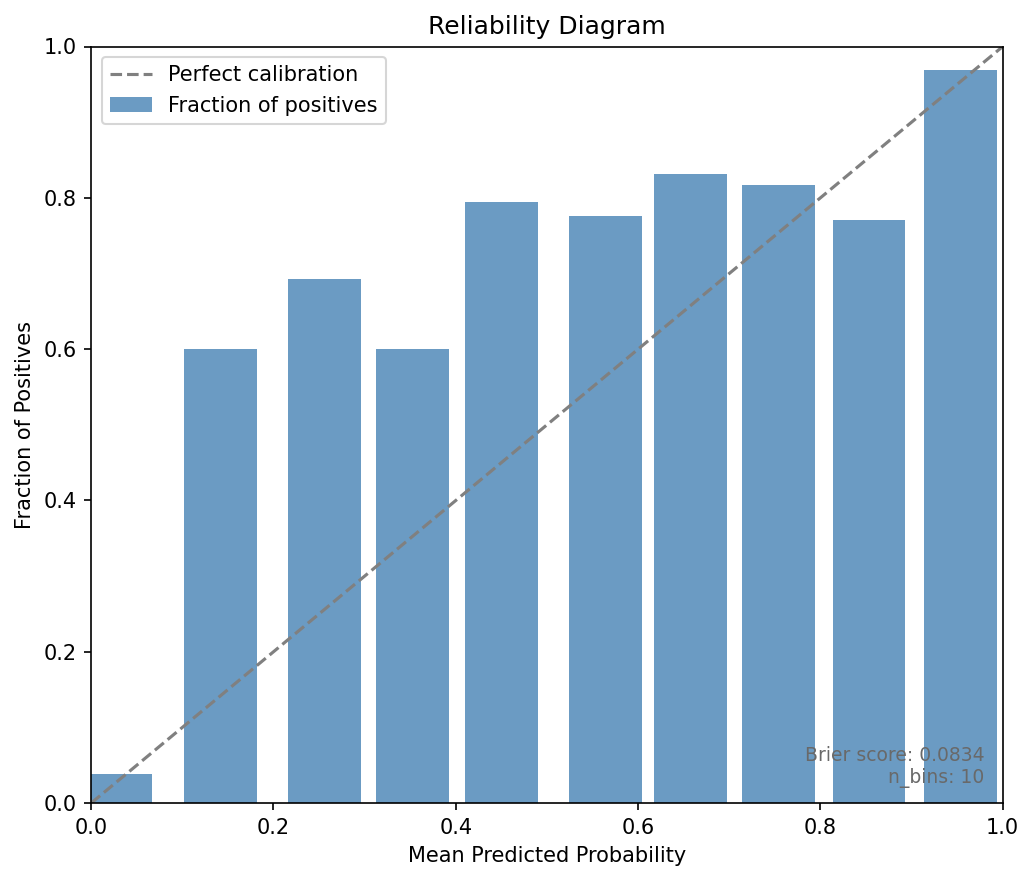

In [5]:
from IPython.display import Image, display

diagram_path = PLOTS_DIR / 'reliability_diagram.png'
if diagram_path.exists():
    display(Image(filename=str(diagram_path)))
else:
    print("reliability_diagram.png not found — run evaluation first.")

## Step 6: Actual vs Predicted Compatibility Score

Plots the actual regression scores against the model's predicted scores on the validation set.
Shows how well the regression head tracks the true compatibility scores across samples.

 Checking/Caching 2520 visual features...


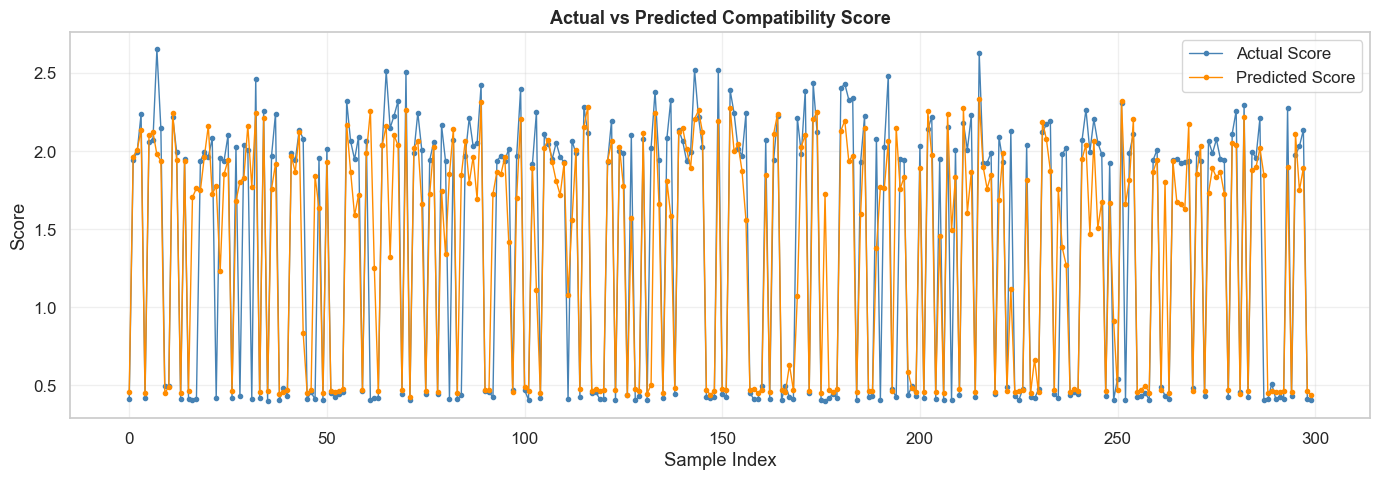

MAE (val): 0.2653
Plot saved to plots/actual_vs_predicted_regression.png


In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from pathlib import Path

from scripts.config import DATA_PROCESSED_DIR, FEATURES_DIR, SAVED_MODELS_DIR, PLOTS_DIR
from scripts.models import HybridFashionModel
from scripts.data_utils import O4UHybridDataset, collate_fn

# --- Load artifacts ---
with open(SAVED_MODELS_DIR / "phys_feature_cols.json") as f:
    phys_feature_cols = json.load(f)

with open(SAVED_MODELS_DIR / "score_normalization.json") as f:
    score_norm = json.load(f)
score_mean = score_norm["mean"]
score_std  = score_norm["std"]

# --- Load val manifest ---
df_val = pd.read_json(DATA_PROCESSED_DIR / "val_imputed_manifest.json")

# --- Device ---
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")

# --- Load model ---
model = HybridFashionModel(phys_input_dim=len(phys_feature_cols)).to(device)
checkpoint = torch.load(str(SAVED_MODELS_DIR / "best_hybrid_model.pth"),
                        map_location=device, weights_only=True)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)
model.eval()

# --- DataLoader ---
val_loader = DataLoader(
    O4UHybridDataset(df_val, str(FEATURES_DIR), phys_feature_cols),
    batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0
)

# --- Run inference ---
actual_scores, predicted_scores = [], []
with torch.no_grad():
    for visual_padded, visual_mask, phys_vecs, reg_labels, bin_labels in val_loader:
        reg_out, _ = model(
            visual_padded.to(device),
            visual_mask.to(device),
            phys_vecs.to(device)
        )
        # Inverse-transform predicted scores from z-score back to original scale
        pred = reg_out.squeeze(-1).cpu().numpy() * score_std + score_mean
        predicted_scores.extend(pred.tolist())
        actual_scores.extend(reg_labels.numpy().tolist())

actual_scores    = np.array(actual_scores)
predicted_scores = np.array(predicted_scores)

# --- Plot: first 300 samples ---
n_plot = min(300, len(actual_scores))
idx    = np.arange(n_plot)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(idx, actual_scores[:n_plot],    marker="o", markersize=3, linewidth=1,
        color="steelblue",  label="Actual Score")
ax.plot(idx, predicted_scores[:n_plot], marker="o", markersize=3, linewidth=1,
        color="darkorange", label="Predicted Score")
ax.set_title("Actual vs Predicted Compatibility Score", fontsize=13, fontweight="bold")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "actual_vs_predicted_regression.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Summary stats ---
mae = float(np.mean(np.abs(actual_scores - predicted_scores)))
print(f"MAE (val): {mae:.4f}")
print(f"Plot saved to plots/actual_vs_predicted_regression.png")

## Step 7: Baseline Comparison

Compares the hybrid model against three baselines:
1. **Pure visual** — logistic regression on mean-pooled CLIP features
2. **Pure physical** — logistic regression on imputed physical features
3. **CLIP zero-shot** — cosine similarity between outfit CLIP features and a text prompt

In [7]:
cmd = [sys.executable, "-m", "scripts.baselines"]
print("Running baselines...")
result = subprocess.run(cmd, cwd=str(Path("..").resolve()))

if result.returncode == 0:
    print("Baselines complete.")
else:
    print(f"Baselines failed with exit code {result.returncode}")

Running baselines...


2026-05-10 20:47:17,074 INFO __main__ — Loaded 99 physical feature columns.
2026-05-10 20:47:17,074 INFO __main__ — Loading training manifest from /Users/hazron/O4U/data/processed/train_imputed_manifest.json …
2026-05-10 20:47:17,241 INFO __main__ —   10080 training records.
2026-05-10 20:47:17,241 INFO __main__ — Loading validation manifest from /Users/hazron/O4U/data/processed/val_imputed_manifest.json …
2026-05-10 20:47:17,276 INFO __main__ —   2520 validation records.
2026-05-10 20:47:17,276 INFO __main__ — Building training feature matrices …
2026-05-10 20:47:20,478 INFO __main__ —   visual: (10080, 512)  physical: (10080, 99)  labels: (10080,)
2026-05-10 20:47:20,478 INFO __main__ — Building validation feature matrices …
2026-05-10 20:47:20,881 INFO __main__ —   visual: (2520, 512)  physical: (2520, 99)  labels: (2520,)
2026-05-10 20:47:20,882 INFO __main__ — Running pure_visual_baseline …
2026-05-10 20:47:21,035 INFO __main__ — Running pure_physical_baseline …


  pure_visual      — ROC-AUC: 0.9347  F1: 0.9107
  pure_physical    — ROC-AUC: 0.5000  F1: 0.7353


2026-05-10 20:47:21,104 INFO __main__ — Running clip_zeroshot_baseline …
2026-05-10 20:47:23,990 INFO httpx — HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-10 20:47:24,100 INFO httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/tokenizer_config.json "HTTP/1.1 200 OK"
2026-05-10 20:47:24,371 INFO httpx — HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-05-10 20:47:24,635 INFO httpx — HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-05-10 20:47:25,039 INFO httpx — HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Tempora

  clip_zeroshot    — ROC-AUC: 0.8109  F1: 0.7353
Baseline results saved to /Users/hazron/O4U/saved_models/baseline_results.json


2026-05-10 20:47:27,274 INFO httpx — HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/main "HTTP/1.1 200 OK"
2026-05-10 20:47:27,988 INFO httpx — HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
2026-05-10 20:47:28,314 INFO httpx — HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
2026-05-10 20:47:28,619 INFO httpx — HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-05-10 20:47:28,919 INFO httpx — HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors "HTTP/1.1 302 Found"


Baselines complete.


In [8]:
baseline_path = SAVED_MODELS_DIR / "baseline_results.json"

if baseline_path.exists():
    with open(baseline_path) as f:
        baselines = json.load(f)

    print("Baseline Results (Validation Split)")
    print("=" * 45)
    print(f"  {'Baseline':<25s}  {'ROC-AUC':>8s}  {'F1':>8s}")
    print("  " + "-" * 43)
    for name, metrics in baselines.items():
        print(f"  {name:<25s}  {metrics['roc_auc']:>8.4f}  {metrics['f1']:>8.4f}")

    # Compare with hybrid model test results
    if results_path.exists():
        hybrid_auc = results.get('roc_auc', {}).get('value')
        hybrid_f1  = results.get('f1', {}).get('value')
        if hybrid_auc and hybrid_f1:
            print(f"  {'HybridFashionModel (test)':<25s}  {hybrid_auc:>8.4f}  {hybrid_f1:>8.4f}")
else:
    print("baseline_results.json not found.")

Baseline Results (Validation Split)
  Baseline                    ROC-AUC        F1
  -------------------------------------------
  pure_visual                  0.9347    0.9107
  pure_physical                0.5000    0.7353
  clip_zeroshot                0.8109    0.7353
  HybridFashionModel (test)    0.9443    0.9191


## Step 8: Color Harmony — Before / After

Compares validation metrics between the baseline model (99 physical features) and the model trained with color harmony features (103 features).

Requires:
- `saved_models/training_config_baseline.json` — rename your pre-harmony `training_config.json` to this
- `saved_models/training_config.json` — produced after retraining with color harmony


In [ ]:
import os

baseline_path = SAVED_MODELS_DIR / "training_config_baseline.json"
harmony_path  = SAVED_MODELS_DIR / "training_config.json"

if not baseline_path.exists():
    print("Baseline config not found.")
    print("Rename your pre-harmony training_config.json to training_config_baseline.json, then retrain.")
elif not harmony_path.exists():
    print("Post-harmony training_config.json not found.")
    print("Re-run NB05 training after generating color_harmony_scores.json.")
else:
    with open(baseline_path) as f:
        baseline = json.load(f)
    with open(harmony_path) as f:
        harmony_cfg = json.load(f)

    metrics = {
        "Model": ["Baseline (99 features)", "+ Color Harmony (103 features)"],
        "Val ROC-AUC": [baseline["best_val_roc_auc"], harmony_cfg["best_val_roc_auc"]],
        "Val F1":      [baseline["best_val_f1"],      harmony_cfg["best_val_f1"]],
    }
    df_cmp = pd.DataFrame(metrics)
    print(df_cmp.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle("Baseline vs + Color Harmony", fontsize=13, fontweight="bold")
    for ax, metric in zip(axes, ["Val ROC-AUC", "Val F1"]):
        bars = ax.bar(df_cmp["Model"], df_cmp[metric], color=["#AAAAAA", "#4A90D9"], width=0.4)
        ax.set_ylim(max(0, min(df_cmp[metric]) - 0.05), 1.0)
        ax.set_title(metric, fontsize=11)
        ax.set_ylabel("Score")
        for bar, val in zip(bars, df_cmp[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=9)
        ax.tick_params(axis="x", labelsize=8)
    plt.tight_layout()
    plt.savefig(str(PLOTS_DIR / "06_before_after_harmony.png"), dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved to plots/06_before_after_harmony.png")


## Step 9: Live Inference Demo

Scores random outfits from the val/test pool against a user's physical attributes.
Only val/test outfit IDs are sampled — training outfits are never shown.

In [9]:
from scripts.inference import digital_wardrobe_inference

# Example user profile — change these to match your user
user_profile = {
    "body_figure": "pear",
    "skin_color": "brown",
    "height": "medium",
    "hair_style": "curly",
    "hair_color": "black",
    "color_contrast": "medium",
}

digital_wardrobe_inference(user_attrs=user_profile, num_outfits=5)

--- Fashion Cognitive Inference System ---

Device: mps
User attributes: {'body_figure': 'pear', 'skin_color': 'brown', 'height': 'medium', 'hair_style': 'curly', 'hair_color': 'black', 'color_contrast': 'medium'}
Physical vector dim: 99
Model loaded.

Scoring 5 outfits...

--- RESULTS ---
  Outfit 3219     | GOOD FIT ( 96.6%) | Score: 2.10
  Outfit 1869     | GOOD FIT ( 96.0%) | Score: 2.05
  Outfit 14034    | GOOD FIT ( 93.4%) | Score: 1.96
  Outfit 1111     | GOOD FIT ( 89.4%) | Score: 1.88
  Outfit 13150    | GOOD FIT ( 64.3%) | Score: 1.52

Top recommendation: Outfit #3219 (96.6% compatible)


## Summary

| Stage | Key Metric |
|---|---|
| Test set evaluation | ROC-AUC, F1, accuracy, Brier score, MAE + 95% CIs |
| Per-group analysis | Accuracy & F1 by body figure, imputed vs. observed |
| Calibration | Reliability diagram + Brier score |
| Actual vs Predicted | Regression score comparison plot |
| Baselines | Pure visual, pure physical, CLIP zero-shot |
| Inference | Live outfit scoring for a user profile |

All results are saved to `saved_models/` and `plots/`.